
## High-Resolution Topology Optimization (Neuro-OC Method)
### **Project Overview:**
Topology optimization is the mathematical process of finding the most efficient distribution of material within a given space, ensuring the structure can withstand applied physical forces while minimizing its weight. Traditionally, this requires running slow, computationally expensive Finite Element Analysis (FEA) simulations thousands of times to test how stress flows through different shapes. It is heavily used in aerospace, automotive, and architectural engineering to design lightweight, organic-looking parts.
### **Our Deep Learning Approach (Neuro-OC):**
This project revolutionizes the process by replacing the slow physics simulator with a Deep Learning surrogate model (a U-Net). We train the AI on a dataset of random, organic structures so it learns the underlying laws of physics. Once trained, the AI can predict the strain energy (stress map) of any shape in mere milliseconds. We then feed these instant AI predictions into a classical engineering algorithm called Optimality Criteria (OC), which uses the stress data to iteratively carve away weak material and reinforce load-bearing paths. The result is a lightning-fast, highly accurate generative design tool capable of sculpting complex, real-world mechanical components.
This notebook demonstrates a 64x64 high-resolution grid with real-world,
practical mechanical engineering applications (Drones, CNCs, Automotive).


In [5]:
%matplotlib inline

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from scipy.ndimage import gaussian_filter
from scipy.sparse import coo_matrix
from scipy.sparse.linalg import spsolve
from tqdm.notebook import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')


Using device: cpu


## Methodology

### **1. FEA solver and training data (64x64)**

- 64x64 grid
- left edge fixed (zero displacement)
- load: unit force at bottom-right corner
- SIMP: stiffness scales with density^3

`fea_solve(rho)` returns element strain energy `ce` - how much each cell contributes to structural compliance.

Dataset:
150 random smooth density maps; FEA is run on each one for training data.


In [7]:
NX, NY = 64, 64

def get_stiffness_matrix(E=1.0, nu=0.3):
    k = np.array([1/2-nu/6, 1/8+nu/8, -1/4-nu/12, -1/8+3*nu/8,
                  -1/4+nu/12, -1/8-nu/8, nu/6, 1/8-3*nu/8])
    return E/(1-nu**2) * np.array([
        [k[0], k[1], k[2], k[3], k[4], k[5], k[6], k[7]],
        [k[1], k[0], k[7], k[6], k[5], k[4], k[3], k[2]],
        [k[2], k[7], k[0], k[5], k[6], k[3], k[4], k[1]],
        [k[3], k[6], k[5], k[0], k[7], k[2], k[1], k[4]],
        [k[4], k[5], k[6], k[7], k[0], k[1], k[2], k[3]],
        [k[5], k[4], k[3], k[2], k[1], k[0], k[7], k[6]],
        [k[6], k[3], k[4], k[1], k[2], k[7], k[0], k[5]],
        [k[7], k[2], k[1], k[4], k[3], k[6], k[5], k[0]]
    ])

def fea_solve(rho, penal=3.0):
    ndof = 2 * (NX + 1) * (NY + 1)
    KE = get_stiffness_matrix()
    ely, elx = np.meshgrid(range(NY), range(NX), indexing='ij')
    n1 = (NY+1)*elx + ely
    n2 = (NY+1)*(elx+1) + ely
    edof = np.array([2*n1, 2*n1+1, 2*n2, 2*n2+1, 2*n2+2, 2*n2+3, 2*n1+2, 2*n1+3]).transpose((1,2,0)).reshape(-1, 8)

    iK = np.kron(edof, np.ones((8,1))).flatten()
    jK = np.kron(edof, np.ones((1,8))).flatten()

    rho_penal = 1e-3 + rho.flatten()**penal * (1.0 - 1e-3)
    sK = (rho_penal[:, None, None] * KE[None, :, :]).flatten()
    K = coo_matrix((sK, (iK, jK)), shape=(ndof, ndof)).tocsc()

    # Load: Point load pulling down on the bottom right corner
    f = np.zeros(ndof)
    f[2*(NX+1)*(NY+1)-1] = 1.0

    # Boundary: Left wall is completely glued/fixed to the wall
    fixeddofs = np.arange(0, 2*(NY+1))
    freedofs = np.setdiff1d(np.arange(ndof), fixeddofs)

    u = np.zeros(ndof)
    u[freedofs] = spsolve(K[freedofs, :][:, freedofs], f[freedofs])

    ce = np.zeros((NY, NX))
    for el in range(NX*NY):
        ue = u[edof[el, :]]
        ce.flat[el] = np.dot(ue, KE @ ue) * rho_penal[el]
    return ce

print('Generating 150 high-resolution training samples...')
X_data, Y_data = [], []
for i in tqdm(range(150)):
    np.random.seed(i)
    rho = gaussian_filter(np.random.uniform(0, 1, (NY, NX)), sigma=3.0)
    rho = (rho - rho.min()) / (rho.max() - rho.min())
    rho = (rho ** 1.5) * 0.98 + 0.01
    X_data.append(rho)
    Y_data.append(fea_solve(rho))

X_tensor = torch.tensor(np.array(X_data), dtype=torch.float32).unsqueeze(1).to(device)
Y_tensor = torch.tensor(np.array(Y_data), dtype=torch.float32).unsqueeze(1).to(device)


Generating 150 high-resolution training samples...


  0%|          | 0/150 [00:00<?, ?it/s]

150 (rho, ce) pairs kept in memory for training. The surrogate learns how the layout affects mechanical response under left (fixed) support and loading (bottom-right).

### **2. U-Net surrogate**

We train the nn to instantly predict the physical strain energy
U-Net trained 80 epochs with MSE loss. Weights are frozen after training.


In [8]:

class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        # Encoder
        self.enc1 = nn.Sequential(nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(), nn.Conv2d(16, 16, 3, padding=1), nn.ReLU())
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = nn.Sequential(nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.Conv2d(32, 32, 3, padding=1), nn.ReLU())
        self.pool2 = nn.MaxPool2d(2)
        self.enc3 = nn.Sequential(nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.Conv2d(64, 64, 3, padding=1), nn.ReLU())

        # Decoder
        self.up1 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec1 = nn.Sequential(nn.Conv2d(64, 32, 3, padding=1), nn.ReLU(), nn.Conv2d(32, 32, 3, padding=1), nn.ReLU())
        self.up2 = nn.ConvTranspose2d(32, 16, 2, stride=2)
        self.dec2 = nn.Sequential(nn.Conv2d(32, 16, 3, padding=1), nn.ReLU(), nn.Conv2d(16, 16, 3, padding=1), nn.ReLU())
        self.final = nn.Conv2d(16, 1, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))

        d1 = self.dec1(torch.cat([self.up1(e3), e2], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d1), e1], dim=1))
        return self.final(d2)

model = UNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.002)
dataset = torch.utils.data.TensorDataset(X_tensor, Y_tensor)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=16, shuffle=True)

print('Training AI Surrogate (80 Epochs)...')
for epoch in range(80):
    model.train()
    for batch_x, batch_y in dataloader:
        optimizer.zero_grad()
        loss = F.mse_loss(model(batch_x), batch_y)
        loss.backward()
        optimizer.step()

# Freeze the AI after training
model.eval()
for param in model.parameters():
    param.requires_grad = False


Training AI Surrogate (80 Epochs)...


### **3. Test cases**

Ten starting designs with the same FEA setup. Each has initial density, a mask (fixed holes/mounts), and a volume target around 40-45% material.

Examples: drone arm, CNC frame, crane hook, engine mount.

During optimization we use fast neural prediction instead of calling `fea_solve` at each step.

In [9]:

manual_cases = []
y, x = np.ogrid[:NY, :NX]

# ==========================================
# CASE 1: Drone Quadcopter Arm
# ==========================================
rho_1 = np.full((NY, NX), 0.5)
mask_1 = np.ones((NY, NX))
mask_tl = y > (x * 0.5 + 16)
mask_br = y < (x * 0.5 - 6)
wire_hole = (x - 28)**2 + (y - 14)**2 <= 4**2
invalid_regions = mask_tl | mask_br | wire_hole
rho_1[invalid_regions] = 0.01
mask_1[invalid_regions] = 0.0
motor_mount = (x - 58)**2 + (y - 26)**2 <= 4**2
rho_1[motor_mount] = 0.99
mask_1[motor_mount] = 0.0

manual_cases.append(("Case 1: Drone Quadcopter Arm", rho_1, mask_1, 0.40))

# ==========================================
# CASE 2: CNC Machine C-Frame Gantry
# ==========================================
rho_2 = np.full((NY, NX), 0.5)
mask_2 = np.ones((NY, NX))
c_cut = (x > 25) & (y > 8) & (y < 24) & (x < 55)
rho_2[c_cut] = 0.01
mask_2[c_cut] = 0.0
tool_hole = (x - 12)**2 + (y - 16)**2 <= 4**2
rho_2[tool_hole] = 0.01
mask_2[tool_hole] = 0.0

manual_cases.append(("Case 2: CNC Machine C-Frame", rho_2, mask_2, 0.45))

# ==========================================
# CASE 3: Automotive Suspension A-Arm (Wishbone)
# ==========================================
rho_3 = np.full((NY, NX), 0.5)
mask_3 = np.ones((NY, NX))
left_cutout = (x < 20) & (y > 10) & (y < 22)
rho_3[left_cutout] = 0.01
mask_3[left_cutout] = 0.0
taper_top = (x > 30) & (y > 26)
taper_bot = (x > 30) & (y < 6)
rho_3[taper_top | taper_bot] = 0.01
mask_3[taper_top | taper_bot] = 0.0
shock_mount = (x - 30)**2 + (y - 16)**2 <= 4**2
rho_3[shock_mount] = 0.01
mask_3[shock_mount] = 0.0

manual_cases.append(("Case 3: Suspension A-Arm", rho_3, mask_3, 0.40))

# ==========================================
# CASE 4: Aerospace Bulkhead (Swiss Cheese)
# ==========================================
rho_4 = np.full((NY, NX), 0.5)
mask_4 = np.ones((NY, NX))
for cx in [20, 44]:
    for cy in [20, 44]:
        hole = (x - cx)**2 + (y - cy)**2 <= 10**2
        rho_4[hole] = 0.01
        mask_4[hole] = 0.0

manual_cases.append(("Case 4: Aerospace Bulkhead", rho_4, mask_4, 0.45))

# ==========================================
# CASE 5: The Engine Mount
# ==========================================
rho_5 = np.full((NY, NX), 0.5)
mask_5 = np.ones((NY, NX))
cut_top = (x < 16) & (y > 44)
cut_bot = (x < 16) & (y < 20)
rho_5[cut_top | cut_bot] = 0.01
mask_5[cut_top | cut_bot] = 0.0
shaft = (x - 32)**2 + (y - 32)**2 <= 12**2
rho_5[shaft] = 0.01
mask_5[shaft] = 0.0

manual_cases.append(("Case 5: Engine Mount", rho_5, mask_5, 0.40))

# ==========================================
# CASE 6: Soft-Core Composite Panel
# ==========================================
rho_6 = np.full((NY, NX), 0.5)
mask_6 = np.ones((NY, NX))
core = (x > 15) & (x < 49) & (y > 15) & (y < 49)
rho_6[core] = 0.15
mask_6[core] = 0.0

manual_cases.append(("Case 6: Soft-Core Composite Panel", rho_6, mask_6, 0.45))

# ==========================================
# CASE 7: The Crane Hook
# ==========================================
rho_7 = np.full((NY, NX), 0.5)
mask_7 = np.ones((NY, NX))
diag_cut = (y < x - 16) & (x > 20)
rho_7[diag_cut] = 0.01
mask_7[diag_cut] = 0.0
c_cut = (x - 32)**2 + (y - 56)**2 <= 16**2
rho_7[c_cut] = 0.01
mask_7[c_cut] = 0.0

manual_cases.append(("Case 7: The Crane Hook", rho_7, mask_7, 0.45))

# ==========================================
# CASE 8: The Serpentine Router
# ==========================================
rho_8 = np.full((NY, NX), 0.5)
mask_8 = np.ones((NY, NX))
slot1 = (x < 40) & (y > 16) & (y < 24)
slot2 = (x > 24) & (y > 40) & (y < 48)
rho_8[slot1 | slot2] = 0.01
mask_8[slot1 | slot2] = 0.0

manual_cases.append(("Case 8: The Serpentine Router", rho_8, mask_8, 0.45))

# ==========================================
# CASE 9: The Foam Lattice Matrix
# ==========================================
rho_9 = np.full((NY, NX), 0.5)
mask_9 = np.ones((NY, NX))
for cx in [16, 32, 48]:
    for cy in [16, 32, 48]:
        box = (x > cx - 5) & (x < cx + 5) & (y > cy - 5) & (y < cy + 5)
        rho_9[box] = 0.15  # Soft foam inclusion
        mask_9[box] = 0.0

manual_cases.append(("Case 9: The Foam Lattice Matrix", rho_9, mask_9, 0.45))

# ==========================================
# CASE 10: Diagonal Barrier Bypass
# ==========================================
rho_10 = np.full((NY, NX), 0.5)
mask_10 = np.ones((NY, NX))
diag_void = np.abs(y - (-x + 50)) < 6
rho_10[diag_void] = 0.01
mask_10[diag_void] = 0.0

manual_cases.append(("Case 10: Diagonal Barrier Bypass", rho_10, mask_10, 0.40))


### **4. Neuro-OC optimization**

OC (Optimality Criteria) updates with predicted strain energy, sensitivity filter, and volume constraint. Settings: 50 iterations, filter sigma 1.7, move limit 0.2. Mask applied each step.

In [ ]:
names='''
# The most dark metallic looking
NUM_ITERATIONS = 50   # How long it cooks (50 to 150)
FILTER_SIGMA   = 1.5  # [1.0 to 3.0] Lower = thin & sharp. Higher = thick & fluid blobby.
MOVE_LIMIT     = 0.1  # [0.05 to 0.2] How fast pixels change. Lower = smoother edges.
POLISH_LOW  = 0.05     # [0.0 to 0.3] Increase to eat away the "grey fog" (whiter voids).
POLISH_HIGH = 0.7    # [0.7 to 1.0] Decrease to force dark greys into solid black metal.

# Metallic grid pattern
NUM_ITERATIONS = 150   # How long it cooks (50 to 150)
FILTER_SIGMA   = 1.5  # [1.0 to 3.0] Lower = thin & sharp. Higher = thick & fluid blobby.
MOVE_LIMIT     = 0.1  # [0.05 to 0.2] How fast pixels change. Lower = smoother edges.
POLISH_LOW  = 0.05    # [0.0 to 0.3] Increase to eat away the "grey fog" (whiter voids).
POLISH_HIGH = 0.8   # [0.7 to 1.0] Decrease to force dark greys into solid black metal.

# Metallic - regular
NUM_ITERATIONS = 150   # How long it cooks (50 to 150)
FILTER_SIGMA   = 2.5  # [1.0 to 3.0] Lower = thin & sharp. Higher = thick & fluid blobby.
MOVE_LIMIT     = 0.3  # [0.05 to 0.2] How fast pixels change. Lower = smoother edges.
POLISH_LOW  = 0.05    # [0.0 to 0.3] Increase to eat away the "grey fog" (whiter voids).
POLISH_HIGH = 0.85  # [0.7 to 1.0] Decrease to force dark greys into solid black metal.

# Weird
NUM_ITERATIONS = 250   # How long it cooks (50 to 150)
FILTER_SIGMA   = 2.5  # [1.0 to 3.0] Lower = thin & sharp. Higher = thick & fluid blobby.
MOVE_LIMIT     = 0.05  # [0.05 to 0.2] How fast pixels change. Lower = smoother edges.
POLISH_LOW  = 0.01    # [0.0 to 0.3] Increase to eat away the "grey fog" (whiter voids).
POLISH_HIGH = 0.8  # [0.7 to 1.0] Decrease to force dark greys into solid black metal.
'''

In [11]:
NUM_ITERATIONS = 50   # How long it cooks (50 to 150)
FILTER_SIGMA   = 1.7  # [1.0 to 3.0] Lower = thin & sharp. Higher = thick & fluid blobby.
MOVE_LIMIT     = 0.2  # [0.05 to 0.2] How fast pixels change. Lower = smoother edges.
POLISH_LOW  = 0.1    # [0.0 to 0.3] Increase to eat away the "grey fog" (whiter voids).
POLISH_HIGH = 0.8  # [0.7 to 1.0] Decrease to force dark greys into solid black metal.

In [12]:

def optimize_shape_neuro_oc(initial_rho, mask_array, target_vol):
    rho = initial_rho.copy()

    for step in range(NUM_ITERATIONS):
        # 1. Ask the AI Surrogate for the Strain Energy prediction
        rho_tensor = torch.tensor(rho, dtype=torch.float32, device=device).unsqueeze(0).unsqueeze(0)
        with torch.no_grad():
            pred_ce = model(rho_tensor)[0, 0].cpu().numpy()

        # 2. Physics Sensitivity: Strain Energy / Density
        pred_ce = np.maximum(pred_ce, 1e-6)
        sensitivity = pred_ce / (rho + 1e-3)

        # 3. Sensitivity Filter (Uses your FILTER_SIGMA knob)
        S_filtered = gaussian_filter(sensitivity, sigma=FILTER_SIGMA)

        # 4. Optimality Criteria Update
        l1, l2 = 0.0, 100000.0
        move = MOVE_LIMIT
        rho_new = np.zeros_like(rho)

        while (l2 - l1) > 1e-4:
            lmid = 0.5 * (l1 + l2)

            rho_new = np.clip(rho * np.sqrt(S_filtered / lmid), rho - move, rho + move)
            rho_new = np.clip(rho_new, 0.01, 1.0)

            # Re-apply manual constraints (Fixed holes, mounts, cutouts)
            rho_new = rho_new * mask_array + initial_rho * (1.0 - mask_array)

            if np.mean(rho_new) > target_vol:
                l1 = lmid
            else:
                l2 = lmid

        rho = rho_new

    # Apply your custom metallic polish contrast stretch
    rho = np.clip((rho - POLISH_LOW) / (POLISH_HIGH - POLISH_LOW), 0.0, 1.0)

    return rho


## Results

Left: input with constraints.  
Right: optimized density. Dark = material, light = void.

Sculpting the 10 mechanical components using Neuro-OC...
Running Case 1: Drone Quadcopter Arm...
Running Case 2: CNC Machine C-Frame...
Running Case 3: Suspension A-Arm...
Running Case 4: Aerospace Bulkhead...
Running Case 5: Engine Mount...
Running Case 6: Soft-Core Composite Panel...
Running Case 7: The Crane Hook...
Running Case 8: The Serpentine Router...
Running Case 9: The Foam Lattice Matrix...
Running Case 10: Diagonal Barrier Bypass...


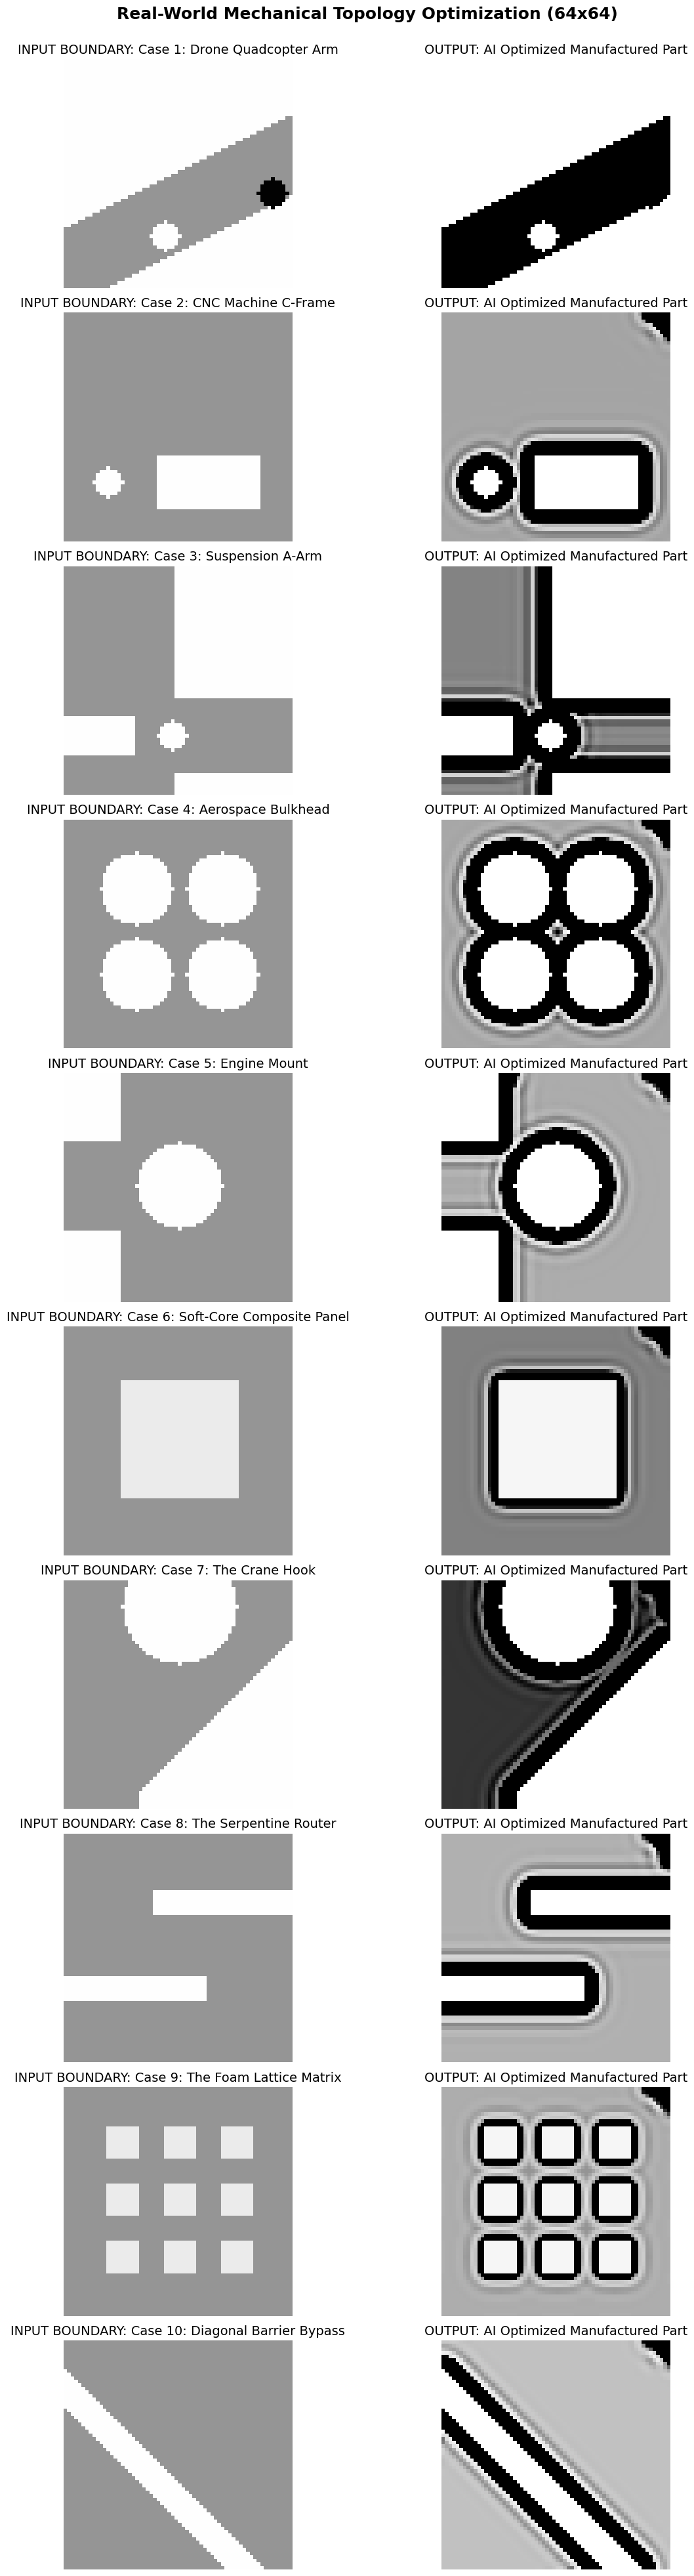

In [13]:

# Run optimization and plot results clearly
num_cases = len(manual_cases)
fig, axes = plt.subplots(num_cases, 2, figsize=(14, 4 * num_cases))
fig.suptitle("Real-World Mechanical Topology Optimization (64x64)", fontsize=18, fontweight='bold')

print(f"Sculpting the {num_cases} mechanical components using Neuro-OC...")
for i, (title, initial_rho, mask_array, target_vol) in enumerate(manual_cases):
    print(f"Running {title}...")
    final_result = optimize_shape_neuro_oc(initial_rho, mask_array, target_vol=target_vol)

    # Left Column: Manual Input Constraints
    axes[i, 0].imshow(initial_rho, cmap='Greys', origin='lower', vmin=0.0, vmax=1.0)
    axes[i, 0].set_title(f"INPUT BOUNDARY: {title}", fontsize=14)
    axes[i, 0].axis('off')

    # Right Column: UNet Output
    axes[i, 1].imshow(final_result, cmap='Greys', origin='lower', vmin=0.0, vmax=1.0)
    axes[i, 1].set_title("OUTPUT: AI Optimized Manufactured Part", fontsize=14)
    axes[i, 1].axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.96) # Adjust top spacing to fit the large dynamic title
plt.show()

Material mostly ends up on paths from the fixed side toward the load. Masked holes stay empty.

## Discussion

Strengths: pipeline runs end to end; FEA uses standard SIMP on 64x64; several different constraint layouts.

Weak points: only 150 training samples; no check how accurate the U-Net is on new shapes; optimizer uses network output, not FEA; no FEA-only baseline or timing comparison in this notebook.



## Conclusions

1. FEA builds training data; a U-Net replaces FEA inside the OC loop (Neuro-OC).
2. Ten test geometries with holes and volume limits optimize to plausible layouts.
3. Speed comes from not running FEA every iteration.